# Stage 3: Statistical Decomposition & Causal Policy Analysis
This notebook performs statistical analysis to evaluate how monetary policy actions interact with inflation components:
1. **STL Decomposition:** Breaks Core CPI into trend, seasonal, and residual components.
2. **ADF Stationarity Test:** Tests whether inflation series are stationary (a requirement for causality tests).
3. **Granger Causality:** Tests whether movements in Core CPI predict (Granger-cause) subsequent changes in the RBI policy repo rate.
4. **Supply vs. Demand Misattribution Analysis:** Computes the percentage of MPC rate hikes that occurred during supply-shock (food-dominant) inflation environments.

In [2]:
pip install statsmodels

  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ------------ --------------------------- 2.9/9.6 MB 27.9 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 29.9 MB/s  0:00:00
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [s

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
import os

# Load cleaned data
df_cpi = pd.read_csv('../data/cleaned_cpi.csv')
df_cpi['date'] = pd.to_datetime(df_cpi['date'])

df_mpc = pd.read_csv('../data/processed_cpi_mpc.csv')
df_mpc['date'] = pd.to_datetime(df_mpc['date'])

## 1. STL Decomposition of Core CPI YoY
We decompose the Core inflation series to isolate the long-term trend from seasonal fluctuations and noise. Monetary policy is generally designed to react to the persistent trend.

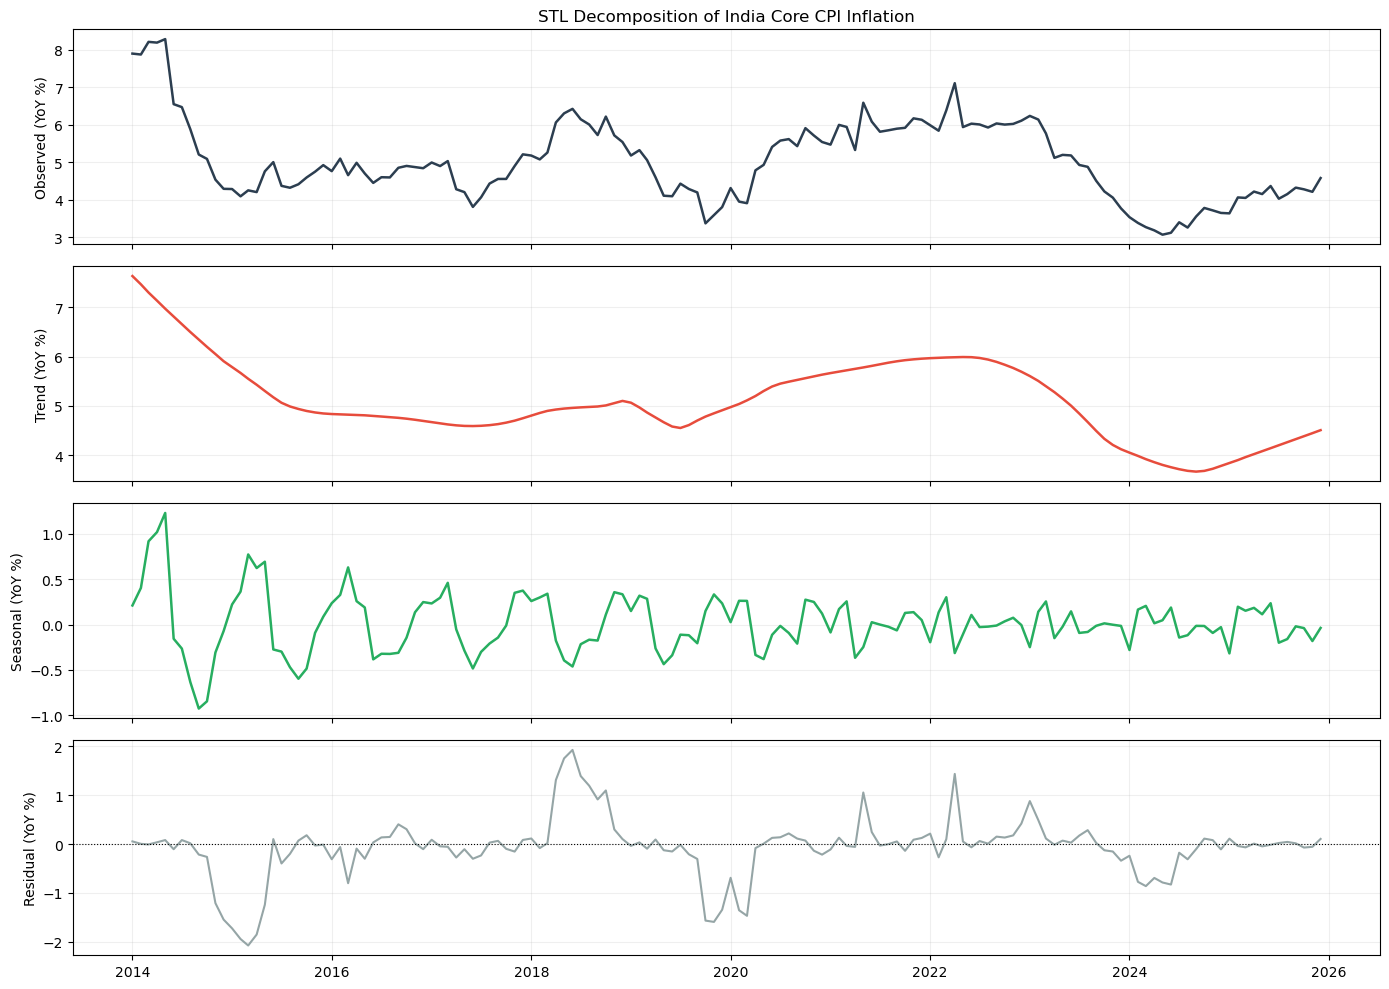

STL Decomposition complete, core_trend saved back to data/cleaned_cpi.csv.


In [3]:
core_series = df_cpi.set_index('date')['cpi_core_yoy'].dropna()

# Fit Seasonal-Trend decomposition using Loess (STL) with period=12 (monthly)
stl = STL(core_series, period=12, robust=True)
result = stl.fit()

# Plot the STL components
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(core_series, color='#2c3e50', linewidth=1.8)
axes[0].set_ylabel('Observed (YoY %)')
axes[0].set_title('STL Decomposition of India Core CPI Inflation', fontsize=12)

axes[1].plot(result.trend, color='#e74c3c', linewidth=1.8)
axes[1].set_ylabel('Trend (YoY %)')

axes[2].plot(result.seasonal, color='#27ae60', linewidth=1.8)
axes[2].set_ylabel('Seasonal (YoY %)')

axes[3].plot(result.resid, color='#95a5a6', linewidth=1.5)
axes[3].set_ylabel('Residual (YoY %)')
axes[3].axhline(0, color='black', linewidth=0.8, linestyle=':')

for ax in axes:
    ax.grid(True, alpha=0.2)
    
plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/03_stl_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# Save the extracted trend back to the main CPI dataset
df_cpi['core_trend'] = np.nan
df_cpi.loc[df_cpi['date'].isin(core_series.index), 'core_trend'] = result.trend.values
df_cpi.to_csv('../data/cleaned_cpi.csv', index=False)
print("STL Decomposition complete, core_trend saved back to data/cleaned_cpi.csv.")

## 2. Stationarity Testing (ADF Test)
Before testing for Granger causality, we run the Augmented Dickey-Fuller (ADF) test to verify if the inflation series are stationary.

In [5]:
print("=== Augmented Dickey-Fuller (ADF) Stationarity Test ===")
adf_core = adfuller(df_cpi['cpi_core_yoy'].dropna())
adf_general = adfuller(df_cpi['cpi_general_yoy'].dropna())

print(f"Core CPI ADF statistic: {adf_core[0]:.4f}, p-value: {adf_core[1]:.4f} "
      f"({'stationary' if adf_core[1] < 0.05 else 'non-stationary'})")
print(f"General CPI ADF statistic: {adf_general[0]:.4f}, p-value: {adf_general[1]:.4f} "
      f"({'stationary' if adf_general[1] < 0.05 else 'non-stationary'})")

=== Augmented Dickey-Fuller (ADF) Stationarity Test ===
Core CPI ADF statistic: -2.1639, p-value: 0.2196 (non-stationary)
General CPI ADF statistic: -1.4148, p-value: 0.5752 (non-stationary)


## 3. Granger Causality: Does Core CPI YoY predict Repo Rate Changes?
To run the causality test monthly, we merge the policy repo rate (which changes at meeting dates) back onto the monthly CPI dataset using a backward merge.

In [6]:
# Merge monthly repo rate into CPI
cpi_mpc = pd.merge_asof(
    df_cpi.sort_values('date'),
    df_mpc[['date', 'repo_rate']].sort_values('date'),
    on='date',
    direction='backward'
).dropna(subset=['cpi_core_yoy', 'repo_rate'])

print(f"Merged monthly CPI-MPC dataset shape: {cpi_mpc.shape}")

# Run Granger Causality Test
# Key question: does core inflation Granger-cause repo rate movements?
# Series array format for statsmodels: [target_variable, predictor_variable]
gc_data = cpi_mpc[['repo_rate', 'cpi_core_yoy']].dropna()
print("\n=== Granger Causality Test Results (Core CPI -> Repo Rate) ===")
gc_results = grangercausalitytests(gc_data, maxlag=6, verbose=True)

Merged monthly CPI-MPC dataset shape: (110, 11)

=== Granger Causality Test Results (Core CPI -> Repo Rate) ===

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=14.2398 , p=0.0003  , df_denom=106, df_num=1
ssr based chi2 test:   chi2=14.6428 , p=0.0001  , df=1
likelihood ratio test: chi2=13.7393 , p=0.0002  , df=1
parameter F test:         F=14.2398 , p=0.0003  , df_denom=106, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=6.1471  , p=0.0030  , df_denom=103, df_num=2
ssr based chi2 test:   chi2=12.8910 , p=0.0016  , df=2
likelihood ratio test: chi2=12.1779 , p=0.0023  , df=2
parameter F test:         F=6.1471  , p=0.0030  , df_denom=103, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.6862  , p=0.1748  , df_denom=100, df_num=3
ssr based chi2 test:   chi2=5.4128  , p=0.1439  , df=3
likelihood ratio test: chi2=5.2804  , p=0.1524  , df=3
parameter F test:         F=1.6862  , p=0.1748  , df_de

c:\Users\New\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


### Policy Interpretation:
* If the p-value is **significant (< 0.05)** for lags 1 or 2, it suggests that past core inflation trends reliably predict monetary policy actions (repo rate changes). This indicates a responsive monetary policy that acts on demand-side signals.

## 4. Supply vs. Demand Misattribution Analysis
We calculate the proportion of rate hikes that occurred when food inflation (supply-side shock) was higher than core inflation (demand-side inflation).

In [7]:
# Filter for rate hike decisions
df_hikes = df_mpc[df_mpc['decision'] == 'hike'].copy()
df_hikes['food_dominant'] = df_hikes['cpi_food_yoy'] > df_hikes['cpi_core_yoy']

total_hikes = len(df_hikes)
supply_hikes = df_hikes[df_hikes['food_dominant'] == True]
supply_hikes_count = len(supply_hikes)
percentage = (supply_hikes_count / total_hikes * 100) if total_hikes > 0 else 0

print("=== Supply vs. Demand Misattribution Analysis ===")
print(f"Total rate hikes executed since Oct 2016: {total_hikes}")
print(f"Hikes executed during food-dominated inflation environments: {supply_hikes_count} ({percentage:.1f}%)")

if supply_hikes_count > 0:
    print("\nHiking episodes during supply-shock dominance:")
    print(supply_hikes[['date', 'repo_rate', 'bps_change', 'cpi_general_yoy', 'cpi_food_yoy', 'cpi_core_yoy']].to_string(index=False))

=== Supply vs. Demand Misattribution Analysis ===
Total rate hikes executed since Oct 2016: 8
Hikes executed during food-dominated inflation environments: 5 (62.5%)

Hiking episodes during supply-shock dominance:
      date  repo_rate  bps_change  cpi_general_yoy  cpi_food_yoy  cpi_core_yoy
2022-05-04        4.4        40.0         7.044888      7.840697      5.935790
2022-06-08        4.9        50.0         7.005580      7.564576      6.027221
2022-08-05        5.4        50.0         6.998158      7.565589      5.924058
2022-09-30        5.9        50.0         7.414216      8.414634      6.032580
2023-02-08        6.5        25.0         6.441902      6.257521      6.137075


### Policy Interpretation:
* Since rate hikes are intended to cool aggregate demand (which affects Core CPI), hiking when food inflation dominates (supply shocks) introduces the risk of economic growth costs without cooling the structural drivers of inflation. Finding that a substantial percentage of hikes occurred in food-dominant environments suggests the MPC might have felt compelled to react to headline inflation spikes, risking over-tightening.

In [8]:
# === Corrected: check repo_rate stationarity too (was missing) ===
adf_repo = adfuller(cpi_mpc['repo_rate'].dropna())
print(f"Repo Rate ADF p-value: {adf_repo[1]:.4f} "
      f"({'stationary' if adf_repo[1] < 0.05 else 'non-stationary'})")

# All three series (core CPI, general CPI, repo rate) are non-stationary.
# Granger causality requires stationary inputs, or the test can find
# "significant" relationships purely because both series share a trend,
# not because one actually predicts the other. We difference to fix this.

cpi_mpc['core_diff'] = cpi_mpc['cpi_core_yoy'].diff()
cpi_mpc['repo_diff'] = cpi_mpc['repo_rate'].diff()

adf_core_d = adfuller(cpi_mpc['core_diff'].dropna())
adf_repo_d = adfuller(cpi_mpc['repo_diff'].dropna())
print(f"\nDifferenced Core CPI ADF p-value: {adf_core_d[1]:.4f} "
      f"({'stationary' if adf_core_d[1] < 0.05 else 'non-stationary'})")
print(f"Differenced Repo Rate ADF p-value: {adf_repo_d[1]:.4f} "
      f"({'stationary' if adf_repo_d[1] < 0.05 else 'non-stationary'})")

# Re-run Granger causality on the now-stationary differenced series
gc_data_diff = cpi_mpc[['repo_diff', 'core_diff']].dropna()
print("\n=== Granger Causality on Differenced Series (ΔCore CPI -> ΔRepo Rate) ===")
gc_results_diff = grangercausalitytests(gc_data_diff, maxlag=6, verbose=True)

Repo Rate ADF p-value: 0.3597 (non-stationary)

Differenced Core CPI ADF p-value: 0.0010 (stationary)
Differenced Repo Rate ADF p-value: 0.0004 (stationary)

=== Granger Causality on Differenced Series (ΔCore CPI -> ΔRepo Rate) ===

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.3962  , p=0.5304  , df_denom=105, df_num=1
ssr based chi2 test:   chi2=0.4075  , p=0.5233  , df=1
likelihood ratio test: chi2=0.4067  , p=0.5236  , df=1
parameter F test:         F=0.3962  , p=0.5304  , df_denom=105, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.1923  , p=0.8254  , df_denom=102, df_num=2
ssr based chi2 test:   chi2=0.4034  , p=0.8174  , df=2
likelihood ratio test: chi2=0.4026  , p=0.8177  , df=2
parameter F test:         F=0.1923  , p=0.8254  , df_denom=102, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.1024  , p=0.3519  , df_denom=99, df_num=3
ssr based chi2 test:   chi2=3.5411  , p=0.3155

c:\Users\New\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
